## ***Install and Import Libraries***

In [1]:
!pip install -q statsmodels


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import os
import sys
import json
import urllib.request
from IPython.display import display, Image

# Statistical Tests
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact, mannwhitneyu, ttest_ind, beta

# Proportion Inference & Confidence Intervals
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep, proportion_effectsize

# Power Analysis & Multiple Testing
from statsmodels.stats.power import NormalIndPower, zt_ind_solve_power
from statsmodels.stats.multitest import multipletests

## ***Config***

In [3]:
# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [4]:
# Configure plotting
# The multi-panel figures below are assembled one subplot per cell, so the inline
# backend is disabled to stop it closing the figure between cells
import matplotlib
matplotlib.use('agg')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (20, 15)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300

In [5]:
# Experiment configuration
ALPHA = 0.05
POWER_TARGET = 0.80
N_BOOTSTRAP = 10000
N_SIMULATIONS = 10000
CONTROL = 'gate_30'
TREATMENT = 'gate_40'

print(f"Significance level (alpha): {ALPHA}")
print(f"Target power: {POWER_TARGET}")
print(f"Control group: {CONTROL}")
print(f"Treatment group: {TREATMENT}")

Significance level (alpha): 0.05
Target power: 0.8
Control group: gate_30
Treatment group: gate_40


In [6]:
# Metric definitions
PRIMARY_METRIC = 'retention_7'
SECONDARY_METRIC = 'retention_1'
GUARDRAIL_METRIC = 'sum_gamerounds'

print(f"Primary metric: {PRIMARY_METRIC}")
print(f"Secondary metric: {SECONDARY_METRIC}")
print(f"Guardrail metric: {GUARDRAIL_METRIC}")

Primary metric: retention_7
Secondary metric: retention_1
Guardrail metric: sum_gamerounds


## ***Data Loading***

In [7]:
# Load the dataset
DATA_URL = "https://raw.githubusercontent.com/ryanschaub/Mobile-Games-A-B-Testing-with-Cookie-Cats/master/cookie_cats.csv"
DATA_PATH = "data/cookie_cats.csv"

if not os.path.exists(DATA_PATH):
    os.makedirs("data", exist_ok=True)
    urllib.request.urlretrieve(DATA_URL, DATA_PATH)
    print(f"Downloaded dataset to: {DATA_PATH}")

df = pd.read_csv(DATA_PATH)
print(f"Loaded dataset from: {DATA_PATH}")
print(f"Shape: {df.shape[0]} rows × {df.shape[1]} columns")

Loaded dataset from: data/cookie_cats.csv
Shape: 90189 rows × 5 columns


In [8]:
# Display first few rows
print(df.head())

   userid  version  sum_gamerounds  retention_1  retention_7
0     116  gate_30               3        False        False
1     337  gate_30              38         True        False
2     377  gate_40             165         True        False
3     483  gate_40               1        False        False
4     488  gate_40             179         True         True


In [9]:
# Check data types
print(df.dtypes)

userid            int64
version             str
sum_gamerounds    int64
retention_1        bool
retention_7        bool
dtype: object


In [10]:
# Check for missing values
missing_count = df.isnull().sum().sum()
if missing_count == 0:
    print("No missing values found")
else:
    print(df.isnull().sum())

No missing values found


In [11]:
# Check for duplicate users
duplicate_count = df['userid'].duplicated().sum()
print(f"Duplicate user IDs: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates(subset='userid')
    print(f"Removed {duplicate_count} duplicate users")

Duplicate user IDs: 0


In [12]:
# Dataset shape
print(f"Dataset Shape")
print(f"Total samples: {df.shape[0]}")
print(f"Total features: {df.shape[1]}")

Dataset Shape
Total samples: 90189
Total features: 5


## ***Data Preprocessing***

In [13]:
# Convert boolean retention flags to integers
df['retention_1'] = df['retention_1'].astype(int)
df['retention_7'] = df['retention_7'].astype(int)
print("Converted retention flags to integer")

Converted retention flags to integer


In [14]:
# Check group assignment counts
version_counts = df['version'].value_counts()
print(version_counts)
print(f"Group Allocation")
print(f"{CONTROL} (control):   {version_counts[CONTROL]} ({version_counts[CONTROL]/len(df)*100:.3f}%)")
print(f"{TREATMENT} (treatment): {version_counts[TREATMENT]} ({version_counts[TREATMENT]/len(df)*100:.3f}%)")

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64
Group Allocation
gate_30 (control):   44700 (49.563%)
gate_40 (treatment): 45489 (50.437%)


In [15]:
# Split into control and treatment frames
control = df[df['version'] == CONTROL]
treatment = df[df['version'] == TREATMENT]

n_control = len(control)
n_treatment = len(treatment)

print(f"Control samples: {n_control}")
print(f"Treatment samples: {n_treatment}")

Control samples: 44700
Treatment samples: 45489


In [16]:
# Display descriptive statistics
print(df.describe())

             userid  sum_gamerounds   retention_1   retention_7
count  9.018900e+04    90189.000000  90189.000000  90189.000000
mean   4.998412e+06       51.872457      0.445210      0.186065
std    2.883286e+06      195.050858      0.496992      0.389161
min    1.160000e+02        0.000000      0.000000      0.000000
25%    2.512230e+06        5.000000      0.000000      0.000000
50%    4.995815e+06       16.000000      0.000000      0.000000
75%    7.496452e+06       51.000000      1.000000      0.000000
max    9.999861e+06    49854.000000      1.000000      1.000000


## ***Exploratory Data Analysis***

In [17]:
# Day-1 retention by group
print("Day-1 Retention by Group")
retention_1_table = pd.crosstab(df['version'], df['retention_1'], margins=True)
print(retention_1_table)

Day-1 Retention by Group
retention_1      0      1    All
version                         
gate_30      24666  20034  44700
gate_40      25370  20119  45489
All          50036  40153  90189


In [18]:
# Day-7 retention by group
print("Day-7 Retention by Group")
retention_7_table = pd.crosstab(df['version'], df['retention_7'], margins=True)
print(retention_7_table)

Day-7 Retention by Group
retention_7      0      1    All
version                         
gate_30      36198   8502  44700
gate_40      37210   8279  45489
All          73408  16781  90189


In [19]:
# Retention rates by group
print("Retention Rates by Group")
retention_rates = df.groupby('version')[['retention_1', 'retention_7']].mean() * 100
print(retention_rates.round(4))

Retention Rates by Group
         retention_1  retention_7
version                          
gate_30      44.8188      19.0201
gate_40      44.2283      18.2000


In [20]:
# Game rounds distribution by group
print("Game Rounds Played by Group")
print(df.groupby('version')['sum_gamerounds'].describe().round(4))

Game Rounds Played by Group
           count     mean       std  min  25%   50%   75%      max
version                                                           
gate_30  44700.0  52.4563  256.7164  0.0  5.0  17.0  50.0  49854.0
gate_40  45489.0  51.2988  103.2944  0.0  5.0  16.0  52.0   2640.0


In [21]:
# Players who never played a round
zero_rounds = (df['sum_gamerounds'] == 0).sum()
print(f"Players with 0 game rounds: {zero_rounds} ({zero_rounds/len(df)*100:.2f}%)")
print(df[df['sum_gamerounds'] == 0]['version'].value_counts())

Players with 0 game rounds: 3994 (4.43%)


version
gate_40    2057
gate_30    1937
Name: count, dtype: int64


In [22]:
# Retention funnel
print("Retention Funnel")
both_retained = ((df['retention_1'] == 1) & (df['retention_7'] == 1)).sum()
only_day1 = ((df['retention_1'] == 1) & (df['retention_7'] == 0)).sum()
only_day7 = ((df['retention_1'] == 0) & (df['retention_7'] == 1)).sum()
neither = ((df['retention_1'] == 0) & (df['retention_7'] == 0)).sum()

print(f"Retained on both day 1 and day 7: {both_retained} ({both_retained/len(df)*100:.2f}%)")
print(f"Retained day 1 only:              {only_day1} ({only_day1/len(df)*100:.2f}%)")
print(f"Retained day 7 only:              {only_day7} ({only_day7/len(df)*100:.2f}%)")
print(f"Retained on neither day:          {neither} ({neither/len(df)*100:.2f}%)")

Retention Funnel
Retained on both day 1 and day 7: 13182 (14.62%)
Retained day 1 only:              26971 (29.90%)
Retained day 7 only:              3599 (3.99%)
Retained on neither day:          46437 (51.49%)


In [23]:
# Correlation between the two retention metrics
retention_corr = df['retention_1'].corr(df['retention_7'])
print(f"Correlation between day-1 and day-7 retention: {retention_corr:.4f}")

Correlation between day-1 and day-7 retention: 0.3274

In [24]:
# Create comprehensive EDA visualizations
print("Creating EDA Visualizations")
fig = plt.figure(figsize=(20, 15))

Creating EDA Visualizations


In [25]:
# Group Allocation
ax1 = plt.subplot(3, 4, 1)
version_counts.plot(kind='bar', ax=ax1, color=['skyblue', 'salmon'], edgecolor='black')
ax1.set_title('Group Allocation', fontweight='bold', fontsize=12)
ax1.set_xlabel('Version')
ax1.set_ylabel('Number of Players')
ax1.set_xticklabels([CONTROL, TREATMENT], rotation=0)

[Text(0, 0, 'gate_30'), Text(1, 0, 'gate_40')]

In [26]:
# Day-1 Retention Rate
ax2 = plt.subplot(3, 4, 2)
retention_rates['retention_1'].plot(kind='bar', ax=ax2, color=['skyblue', 'salmon'], edgecolor='black')
ax2.set_title('Day-1 Retention Rate', fontweight='bold', fontsize=12)
ax2.set_xlabel('Version')
ax2.set_ylabel('Retention Rate (%)')
ax2.set_xticklabels([CONTROL, TREATMENT], rotation=0)
ax2.set_ylim(40, 46)
for i, v in enumerate(retention_rates['retention_1']):
    ax2.text(i, v + 0.1, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)

In [27]:
# Day-7 Retention Rate
ax3 = plt.subplot(3, 4, 3)
retention_rates['retention_7'].plot(kind='bar', ax=ax3, color=['skyblue', 'salmon'], edgecolor='black')
ax3.set_title('Day-7 Retention Rate', fontweight='bold', fontsize=12)
ax3.set_xlabel('Version')
ax3.set_ylabel('Retention Rate (%)')
ax3.set_xticklabels([CONTROL, TREATMENT], rotation=0)
ax3.set_ylim(16, 20)
for i, v in enumerate(retention_rates['retention_7']):
    ax3.text(i, v + 0.08, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=10)

In [28]:
# Game Rounds Distribution (log scale)
ax4 = plt.subplot(3, 4, 4)
ax4.hist(np.log1p(control['sum_gamerounds']), bins=50, alpha=0.5, label=CONTROL, color='blue')
ax4.hist(np.log1p(treatment['sum_gamerounds']), bins=50, alpha=0.5, label=TREATMENT, color='red')
ax4.set_title('Game Rounds Distribution (log1p)', fontweight='bold', fontsize=12)
ax4.set_xlabel('log1p(Game Rounds)')
ax4.set_ylabel('Frequency')
ax4.legend()

In [29]:
# Game Rounds Boxplot
ax5 = plt.subplot(3, 4, 5)
df.boxplot(column='sum_gamerounds', by='version', ax=ax5)
ax5.set_title('Game Rounds by Version', fontweight='bold', fontsize=12)
ax5.set_xlabel('Version')
ax5.set_ylabel('Game Rounds')
ax5.set_yscale('log')
plt.suptitle('')

Text(0.5, 0.98, '')

In [30]:
# Retention Funnel
ax6 = plt.subplot(3, 4, 6)
funnel_labels = ['Both Days', 'Day 1 Only', 'Day 7 Only', 'Neither']
funnel_values = [both_retained, only_day1, only_day7, neither]
ax6.bar(funnel_labels, funnel_values, color=['seagreen', 'skyblue', 'gold', 'lightcoral'], edgecolor='black')
ax6.set_title('Retention Funnel', fontweight='bold', fontsize=12)
ax6.set_xlabel('Retention Pattern')
ax6.set_ylabel('Number of Players')
ax6.set_xticklabels(funnel_labels, rotation=45, ha='right')

[Text(0, 0, 'Both Days'),
 Text(1, 0, 'Day 1 Only'),
 Text(2, 0, 'Day 7 Only'),
 Text(3, 0, 'Neither')]

In [31]:
# Retention Rate by Game Rounds Bucket
ax7 = plt.subplot(3, 4, 7)
rounds_bucket = pd.cut(df['sum_gamerounds'], bins=[-1, 0, 5, 20, 50, 100, 1000000],
                       labels=['0', '1-5', '6-20', '21-50', '51-100', '100+'])
bucket_retention = df.groupby(rounds_bucket, observed=True)['retention_7'].mean() * 100
bucket_retention.plot(kind='bar', ax=ax7, color='mediumpurple', edgecolor='black')
ax7.set_title('Day-7 Retention by Rounds Played', fontweight='bold', fontsize=12)
ax7.set_xlabel('Game Rounds Bucket')
ax7.set_ylabel('Day-7 Retention (%)')
ax7.set_xticklabels(bucket_retention.index, rotation=45, ha='right')

[Text(0, 0, '0'),
 Text(1, 0, '1-5'),
 Text(2, 0, '6-20'),
 Text(3, 0, '21-50'),
 Text(4, 0, '51-100'),
 Text(5, 0, '100+')]

In [32]:
# Player Volume by Game Rounds Bucket
ax8 = plt.subplot(3, 4, 8)
bucket_counts = rounds_bucket.value_counts().sort_index()
bucket_counts.plot(kind='bar', ax=ax8, color='steelblue', edgecolor='black')
ax8.set_title('Player Volume by Rounds Played', fontweight='bold', fontsize=12)
ax8.set_xlabel('Game Rounds Bucket')
ax8.set_ylabel('Number of Players')
ax8.set_xticklabels(bucket_counts.index, rotation=45, ha='right')

[Text(0, 0, '0'),
 Text(1, 0, '1-5'),
 Text(2, 0, '6-20'),
 Text(3, 0, '21-50'),
 Text(4, 0, '51-100'),
 Text(5, 0, '100+')]

In [33]:
# Cumulative Game Rounds Distribution
ax9 = plt.subplot(3, 4, 9)
ax9.plot(np.sort(control['sum_gamerounds']), np.linspace(0, 1, n_control), label=CONTROL, color='blue', lw=2)
ax9.plot(np.sort(treatment['sum_gamerounds']), np.linspace(0, 1, n_treatment), label=TREATMENT, color='red', lw=2)
ax9.set_title('Cumulative Distribution of Game Rounds', fontweight='bold', fontsize=12)
ax9.set_xlabel('Game Rounds')
ax9.set_ylabel('Cumulative Proportion')
ax9.set_xscale('symlog')
ax9.legend()

In [34]:
# Retention Rate Difference
ax10 = plt.subplot(3, 4, 10)
diff_labels = ['Day-1 Retention', 'Day-7 Retention']
diff_values = [retention_rates.loc[TREATMENT, 'retention_1'] - retention_rates.loc[CONTROL, 'retention_1'],
               retention_rates.loc[TREATMENT, 'retention_7'] - retention_rates.loc[CONTROL, 'retention_7']]
ax10.bar(diff_labels, diff_values, color=['lightcoral', 'indianred'], edgecolor='black')
ax10.axhline(0, color='black', lw=1)
ax10.set_title('Treatment Effect (pp)', fontweight='bold', fontsize=12)
ax10.set_ylabel('Difference (percentage points)')
for i, v in enumerate(diff_values):
    ax10.text(i, v - 0.05, f'{v:+.3f}pp', ha='center', fontweight='bold', fontsize=10)

In [35]:
# Median Game Rounds by Group
ax11 = plt.subplot(3, 4, 11)
median_rounds = df.groupby('version')['sum_gamerounds'].median()
median_rounds.plot(kind='bar', ax=ax11, color=['skyblue', 'salmon'], edgecolor='black')
ax11.set_title('Median Game Rounds', fontweight='bold', fontsize=12)
ax11.set_xlabel('Version')
ax11.set_ylabel('Median Rounds')
ax11.set_xticklabels([CONTROL, TREATMENT], rotation=0)
for i, v in enumerate(median_rounds):
    ax11.text(i, v + 0.2, f'{v:.0f}', ha='center', fontweight='bold', fontsize=10)

In [36]:
# Correlation Heatmap
ax12 = plt.subplot(3, 4, 12)
numerical_cols = ['sum_gamerounds', 'retention_1', 'retention_7']
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.3f', cmap='coolwarm', ax=ax12,
            cbar_kws={'label': 'Correlation'}, linewidths=0.5)
ax12.set_title('Correlation Heatmap', fontweight='bold', fontsize=12)

Text(0.5, 1.0, 'Correlation Heatmap')

EDA visualizations saved as 'outputs/eda_comprehensive_analysis.png'


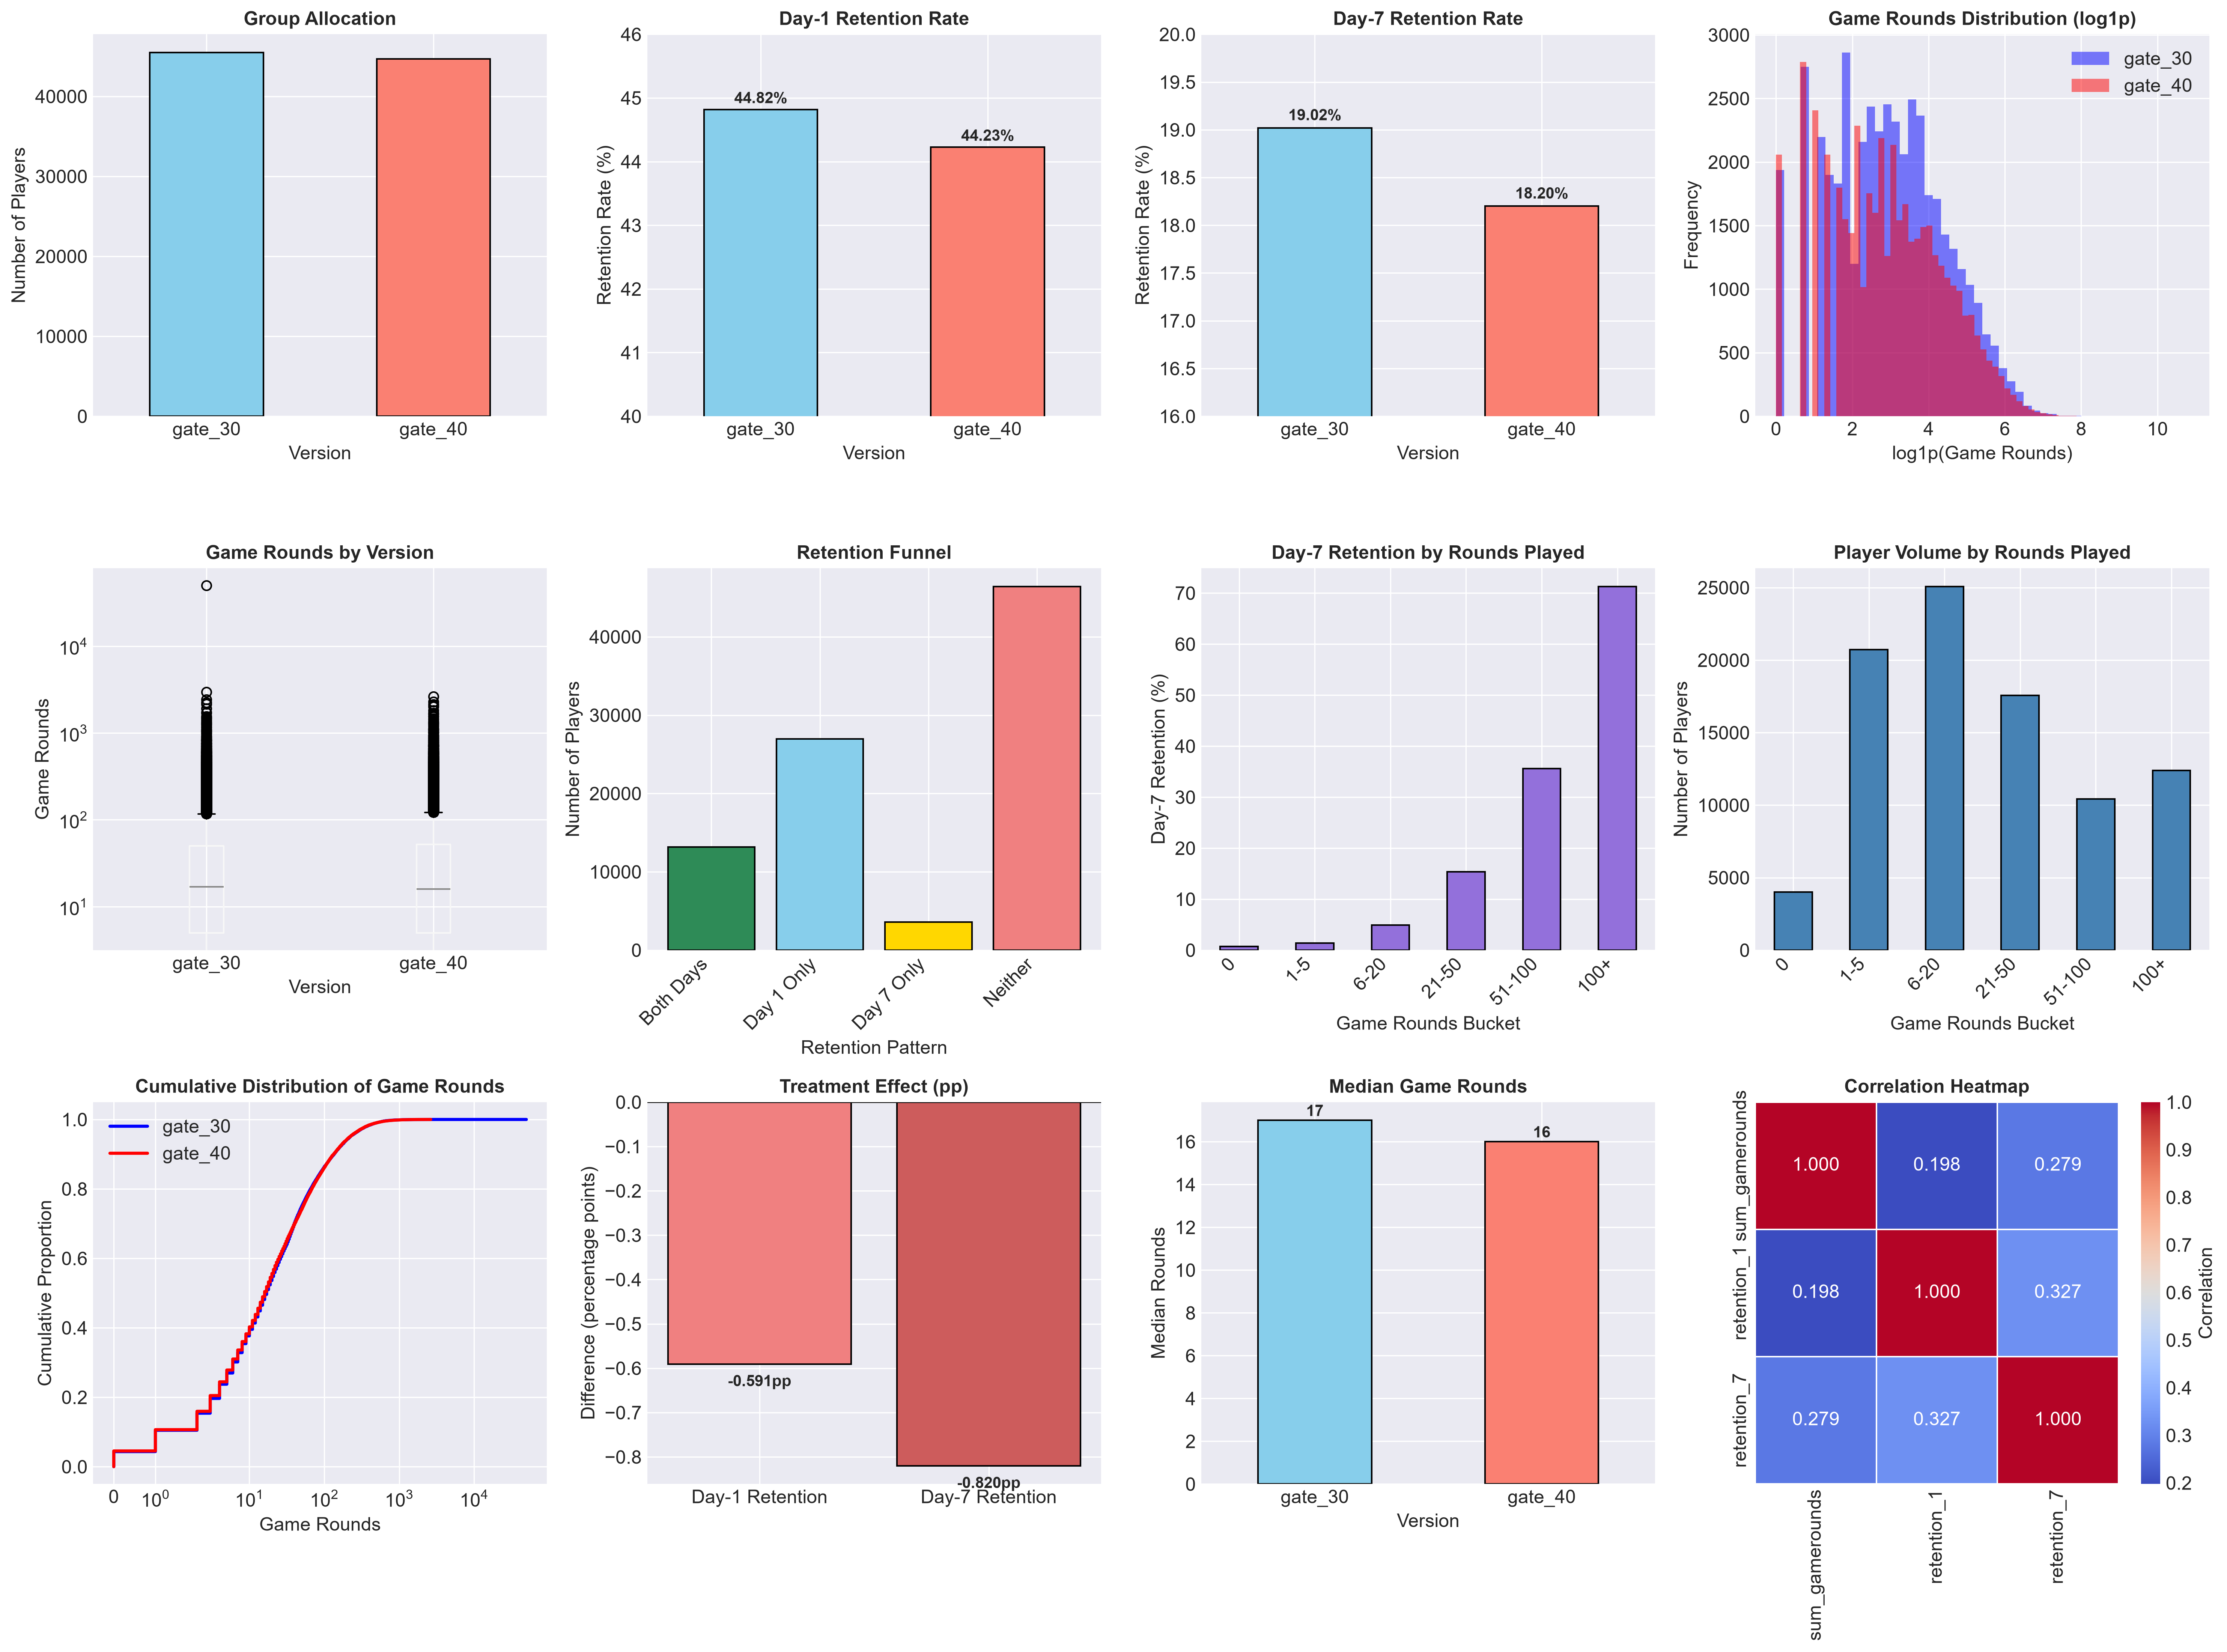

In [37]:
plt.tight_layout()
plt.savefig('outputs/eda_comprehensive_analysis.png', dpi=300, bbox_inches='tight')
plt.close()
print("EDA visualizations saved as 'outputs/eda_comprehensive_analysis.png'")
display(Image(filename='outputs/eda_comprehensive_analysis.png', width=1100))

## ***Experiment Validity Checks***

### ***Sample Ratio Mismatch***

In [38]:
# Sample ratio mismatch test
expected_ratio = 0.5
observed_control_share = n_control / (n_control + n_treatment)

srm_chi2, srm_p = stats.chisquare(f_obs=[n_control, n_treatment],
                                  f_exp=[(n_control + n_treatment) * expected_ratio,
                                         (n_control + n_treatment) * (1 - expected_ratio)])

print(f"Sample Ratio Mismatch Check")
print(f"Expected allocation: {expected_ratio:.4f} / {1-expected_ratio:.4f}")
print(f"Observed allocation: {observed_control_share:.4f} / {1-observed_control_share:.4f}")
print(f"Chi-square statistic: {srm_chi2:.4f}")
print(f"P-value: {srm_p:.6f}")

Sample Ratio Mismatch Check
Expected allocation: 0.5000 / 0.5000
Observed allocation: 0.4956 / 0.5044
Chi-square statistic: 6.9024
P-value: 0.008608


In [39]:
# Evaluate against standard SRM alerting thresholds
SRM_THRESHOLD_STRICT = 0.0005
SRM_THRESHOLD_DEFAULT = 0.001

print(f"SRM Verdict")
print(f"P-value vs strict threshold ({SRM_THRESHOLD_STRICT}):  {'ALERT' if srm_p < SRM_THRESHOLD_STRICT else 'PASS'}")
print(f"P-value vs default threshold ({SRM_THRESHOLD_DEFAULT}): {'ALERT' if srm_p < SRM_THRESHOLD_DEFAULT else 'PASS'}")
print(f"Absolute imbalance: {abs(n_control - n_treatment)} players ({abs(observed_control_share - expected_ratio)*100:.4f}pp from parity)")

SRM Verdict
P-value vs strict threshold (0.0005):  PASS
P-value vs default threshold (0.001): PASS
Absolute imbalance: 789 players (0.4374pp from parity)


### ***Outlier Detection***

In [40]:
# Identify extreme values in the guardrail metric
rounds_q99 = df['sum_gamerounds'].quantile(0.99)
rounds_max = df['sum_gamerounds'].max()

print(f"Game Rounds Outlier Check")
print(f"99th percentile: {rounds_q99:.1f}")
print(f"Maximum value:   {rounds_max}")
print(f"Ratio of max to 99th percentile: {rounds_max/rounds_q99:.1f}x")

Game Rounds Outlier Check
99th percentile: 493.0
Maximum value:   49854
Ratio of max to 99th percentile: 101.1x


In [41]:
# Inspect records above a plausible engagement ceiling
OUTLIER_THRESHOLD = 10000
outliers = df[df['sum_gamerounds'] > OUTLIER_THRESHOLD]
print(f"Records above {OUTLIER_THRESHOLD} rounds: {len(outliers)}")
print(outliers)

Records above 10000 rounds: 1
        userid  version  sum_gamerounds  retention_1  retention_7
57702  6390605  gate_30           49854            0            1


In [42]:
# Build an outlier-excluded frame for guardrail robustness checks
df_no_outlier = df[df['sum_gamerounds'] <= OUTLIER_THRESHOLD]
control_no_outlier = df_no_outlier[df_no_outlier['version'] == CONTROL]
treatment_no_outlier = df_no_outlier[df_no_outlier['version'] == TREATMENT]

print(f"Rows retained: {len(df_no_outlier)} of {len(df)}")
print(f"Rows excluded: {len(df) - len(df_no_outlier)}")

Rows retained: 90188 of 90189
Rows excluded: 1


### ***Power Analysis***

In [43]:
# Baseline conversion rates from the control group
baseline_r1 = control['retention_1'].mean()
baseline_r7 = control['retention_7'].mean()

print(f"Baseline Rates (control group)")
print(f"Day-1 retention: {baseline_r1*100:.4f}%")
print(f"Day-7 retention: {baseline_r7*100:.4f}%")

Baseline Rates (control group)
Day-1 retention: 44.8188%
Day-7 retention: 19.0201%


In [44]:
# Minimum detectable effect at the achieved sample size
power_analysis = NormalIndPower()

def compute_mde(baseline, n1, n2, alpha=ALPHA, power=POWER_TARGET):
    """Return the smallest absolute lift detectable at the given sample sizes."""
    effect_size = power_analysis.solve_power(effect_size=None, nobs1=n1, ratio=n2/n1,
                                            alpha=alpha, power=power)
    lo, hi = 0.0, 1.0 - baseline
    for _ in range(200):
        mid = (lo + hi) / 2
        if proportion_effectsize(baseline + mid, baseline) < effect_size:
            lo = mid
        else:
            hi = mid
    return (lo + hi) / 2

In [45]:
mde_r1 = compute_mde(baseline_r1, n_control, n_treatment)
mde_r7 = compute_mde(baseline_r7, n_control, n_treatment)

print(f"Minimum Detectable Effect at n={n_control}/{n_treatment}, alpha={ALPHA}, power={POWER_TARGET}")
print(f"Day-1 retention: {mde_r1*100:.4f}pp absolute ({mde_r1/baseline_r1*100:.3f}% relative)")
print(f"Day-7 retention: {mde_r7*100:.4f}pp absolute ({mde_r7/baseline_r7*100:.3f}% relative)")

Minimum Detectable Effect at n=44700/45489, alpha=0.05, power=0.8
Day-1 retention: 0.9287pp absolute (2.072% relative)
Day-7 retention: 0.7376pp absolute (3.878% relative)


In [46]:
# Sample size required per arm across a range of relative lifts
print(f"Sample Size Requirements per Arm (day-7 retention, alpha={ALPHA}, power={POWER_TARGET})")
sample_size_rows = []
for rel_lift in [0.01, 0.02, 0.03, 0.05, 0.075, 0.10]:
    effect_size = proportion_effectsize(baseline_r7 * (1 + rel_lift), baseline_r7)
    n_required = power_analysis.solve_power(effect_size=effect_size, nobs1=None, ratio=1.0,
                                           alpha=ALPHA, power=POWER_TARGET)
    sample_size_rows.append({'relative_lift': f"{rel_lift*100:.1f}%",
                             'absolute_lift_pp': round(baseline_r7 * rel_lift * 100, 4),
                             'n_per_arm': int(np.ceil(n_required))})

sample_size_df = pd.DataFrame(sample_size_rows)
print(sample_size_df.to_string(index=False))

Sample Size Requirements per Arm (day-7 retention, alpha=0.05, power=0.8)
relative_lift  absolute_lift_pp  n_per_arm
         1.0%            0.1902     670894
         2.0%            0.3804     168357
         3.0%            0.5706      75106
         5.0%            0.9510      27238
         7.5%            1.4265      12216
        10.0%            1.9020       6932


## ***Primary Metric Analysis***

In [47]:
# Reusable metric analysis routine
def analyze_proportion_metric(metric, control_frame, treatment_frame):
    """Run the full inference suite for one binary metric."""
    c, t = control_frame[metric], treatment_frame[metric]
    nc, nt = len(c), len(t)
    xc, xt = int(c.sum()), int(t.sum())
    pc, pt = xc / nc, xt / nt

    z_stat, z_p = proportions_ztest([xt, xc], [nt, nc])
    table = np.array([[xt, nt - xt], [xc, nc - xc]])
    chi2_stat, chi2_p, dof, expected = chi2_contingency(table, correction=False)
    odds_ratio, fisher_p = fisher_exact(table)
    ci_low, ci_high = confint_proportions_2indep(xt, nt, xc, nc, method='wald')
    effect_size = proportion_effectsize(pt, pc)
    achieved_power = power_analysis.power(effect_size=abs(effect_size), nobs1=nc,
                                          ratio=nt/nc, alpha=ALPHA)

    return {
        'metric': metric,
        'n_control': nc, 'n_treatment': nt,
        'x_control': xc, 'x_treatment': xt,
        'rate_control': pc, 'rate_treatment': pt,
        'absolute_lift': pt - pc,
        'relative_lift': pt / pc - 1,
        'z_statistic': z_stat, 'z_pvalue': z_p,
        'chi2_statistic': chi2_stat, 'chi2_pvalue': chi2_p,
        'odds_ratio': odds_ratio, 'fisher_pvalue': fisher_p,
        'ci_low': ci_low, 'ci_high': ci_high,
        'cohens_h': effect_size, 'achieved_power': achieved_power,
    }

In [48]:
# Dictionary to store metric results
metric_results = {}

### ***Day-7 Retention***

In [49]:
r7 = analyze_proportion_metric('retention_7', control, treatment)
metric_results['retention_7'] = r7

In [50]:
print(f"Day-7 Retention")
print(f"{CONTROL}:   {r7['x_control']} / {r7['n_control']} = {r7['rate_control']*100:.4f}%")
print(f"{TREATMENT}: {r7['x_treatment']} / {r7['n_treatment']} = {r7['rate_treatment']*100:.4f}%")

Day-7 Retention
gate_30:   8502 / 44700 = 19.0201%
gate_40: 8279 / 45489 = 18.2000%


In [51]:
print(f"Effect Size")
print(f"Absolute lift: {r7['absolute_lift']*100:+.4f}pp")
print(f"Relative lift: {r7['relative_lift']*100:+.4f}%")
print(f"95% CI on absolute lift: [{r7['ci_low']*100:+.4f}pp, {r7['ci_high']*100:+.4f}pp]")

Effect Size
Absolute lift: -0.8201pp
Relative lift: -4.3119%
95% CI on absolute lift: [-1.3282pp, -0.3121pp]


In [52]:
print(f"Hypothesis Tests")
print(f"Two-proportion z-test: z = {r7['z_statistic']:.4f}, p = {r7['z_pvalue']:.6f}")
print(f"Chi-square test:       chi2 = {r7['chi2_statistic']:.4f}, p = {r7['chi2_pvalue']:.6f}")
print(f"Fisher exact test:     OR = {r7['odds_ratio']:.4f}, p = {r7['fisher_pvalue']:.6f}")

Hypothesis Tests
Two-proportion z-test: z = -3.1644, p = 0.001554
Chi-square test:       chi2 = 10.0132, p = 0.001554
Fisher exact test:     OR = 0.9473, p = 0.001591


In [53]:
print(f"Power")
print(f"Cohen's h: {r7['cohens_h']:.6f}")
print(f"Achieved power at observed effect: {r7['achieved_power']:.4f}")
print(f"Significant at alpha={ALPHA}: {r7['z_pvalue'] < ALPHA}")

Power
Cohen's h: -0.021074
Achieved power at observed effect: 0.8858
Significant at alpha=0.05: True


### ***Day-1 Retention***

In [54]:
r1 = analyze_proportion_metric('retention_1', control, treatment)
metric_results['retention_1'] = r1

In [55]:
print(f"Day-1 Retention")
print(f"{CONTROL}:   {r1['x_control']} / {r1['n_control']} = {r1['rate_control']*100:.4f}%")
print(f"{TREATMENT}: {r1['x_treatment']} / {r1['n_treatment']} = {r1['rate_treatment']*100:.4f}%")

Day-1 Retention
gate_30:   20034 / 44700 = 44.8188%
gate_40: 20119 / 45489 = 44.2283%


In [56]:
print(f"Effect Size")
print(f"Absolute lift: {r1['absolute_lift']*100:+.4f}pp")
print(f"Relative lift: {r1['relative_lift']*100:+.4f}%")
print(f"95% CI on absolute lift: [{r1['ci_low']*100:+.4f}pp, {r1['ci_high']*100:+.4f}pp]")

Effect Size
Absolute lift: -0.5905pp
Relative lift: -1.3176%
95% CI on absolute lift: [-1.2392pp, +0.0582pp]


In [57]:
print(f"Hypothesis Tests")
print(f"Two-proportion z-test: z = {r1['z_statistic']:.4f}, p = {r1['z_pvalue']:.6f}")
print(f"Chi-square test:       chi2 = {r1['chi2_statistic']:.4f}, p = {r1['chi2_pvalue']:.6f}")
print(f"Fisher exact test:     OR = {r1['odds_ratio']:.4f}, p = {r1['fisher_pvalue']:.6f}")

Hypothesis Tests
Two-proportion z-test: z = -1.7841, p = 0.074410
Chi-square test:       chi2 = 3.1830, p = 0.074410
Fisher exact test:     OR = 0.9764, p = 0.074707


In [58]:
print(f"Power")
print(f"Cohen's h: {r1['cohens_h']:.6f}")
print(f"Achieved power at observed effect: {r1['achieved_power']:.4f}")
print(f"Significant at alpha={ALPHA}: {r1['z_pvalue'] < ALPHA}")

Power
Cohen's h: -0.011882
Achieved power at observed effect: 0.4303
Significant at alpha=0.05: False


In [59]:
# Sample size that would have been needed to detect the observed day-1 effect
n_needed_r1 = power_analysis.solve_power(effect_size=abs(r1['cohens_h']), nobs1=None,
                                        ratio=1.0, alpha=ALPHA, power=POWER_TARGET)
print(f"Observed day-1 effect: {r1['absolute_lift']*100:+.4f}pp")
print(f"Sample size per arm needed for {POWER_TARGET:.0%} power at that effect: {int(np.ceil(n_needed_r1))}")
print(f"Actual sample size per arm: {min(n_control, n_treatment)}")
print(f"Shortfall factor: {n_needed_r1/min(n_control, n_treatment):.2f}x")

Observed day-1 effect: -0.5905pp
Sample size per arm needed for 80% power at that effect: 111190
Actual sample size per arm: 44700
Shortfall factor: 2.49x


## ***Guardrail Metric Analysis***

### ***Game Rounds Played***

In [60]:
# Central tendency of the guardrail metric
rounds_control = control['sum_gamerounds']
rounds_treatment = treatment['sum_gamerounds']

print(f"Game Rounds Played")
print(f"{CONTROL}:   mean = {rounds_control.mean():.4f}, median = {rounds_control.median():.1f}")
print(f"{TREATMENT}: mean = {rounds_treatment.mean():.4f}, median = {rounds_treatment.median():.1f}")
print(f"Absolute difference in means: {rounds_treatment.mean() - rounds_control.mean():+.4f} rounds")

Game Rounds Played
gate_30:   mean = 52.4563, median = 17.0
gate_40: mean = 51.2988, median = 16.0
Absolute difference in means: -1.1575 rounds


In [61]:
# Welch t-test on the full sample
welch_t, welch_p = ttest_ind(rounds_treatment, rounds_control, equal_var=False)
print(f"Welch t-test (full sample)")
print(f"t = {welch_t:.4f}, p = {welch_p:.6f}")
print(f"Significant at alpha={ALPHA}: {welch_p < ALPHA}")

Welch t-test (full sample)
t = -0.8854, p = 0.375924
Significant at alpha=0.05: False


In [62]:
# Mann-Whitney U test on the full sample
mw_u, mw_p = mannwhitneyu(rounds_treatment, rounds_control, alternative='two-sided')
print(f"Mann-Whitney U test (full sample)")
print(f"U = {mw_u:.1f}, p = {mw_p:.6f}")
print(f"Significant at alpha={ALPHA}: {mw_p < ALPHA}")

Mann-Whitney U test (full sample)
U = 1009027049.5, p = 0.050209
Significant at alpha=0.05: False


In [63]:
# Welch t-test excluding the extreme record
rounds_control_clean = control_no_outlier['sum_gamerounds']
rounds_treatment_clean = treatment_no_outlier['sum_gamerounds']

welch_t_clean, welch_p_clean = ttest_ind(rounds_treatment_clean, rounds_control_clean, equal_var=False)
print(f"Welch t-test (outlier excluded)")
print(f"{CONTROL}:   mean = {rounds_control_clean.mean():.4f}")
print(f"{TREATMENT}: mean = {rounds_treatment_clean.mean():.4f}")
print(f"Absolute difference in means: {rounds_treatment_clean.mean() - rounds_control_clean.mean():+.4f} rounds")
print(f"t = {welch_t_clean:.4f}, p = {welch_p_clean:.6f}")

Welch t-test (outlier excluded)


gate_30:   mean = 51.3421


gate_40: mean = 51.2988
Absolute difference in means: -0.0433 rounds
t = -0.0634, p = 0.949469


In [64]:
# Compare the guardrail conclusion with and without the extreme record
print(f"Guardrail Sensitivity to the Extreme Record")
print(f"Mean difference including outlier: {rounds_treatment.mean() - rounds_control.mean():+.4f} rounds (p = {welch_p:.6f})")
print(f"Mean difference excluding outlier: {rounds_treatment_clean.mean() - rounds_control_clean.mean():+.4f} rounds (p = {welch_p_clean:.6f})")
print(f"The single largest record accounts for {abs((rounds_treatment.mean() - rounds_control.mean()) - (rounds_treatment_clean.mean() - rounds_control_clean.mean())):.4f} rounds of the gap")

Guardrail Sensitivity to the Extreme Record
Mean difference including outlier: -1.1575 rounds (p = 0.375924)
Mean difference excluding outlier: -0.0433 rounds (p = 0.949469)
The single largest record accounts for 1.1142 rounds of the gap


## ***Permutation Test***

In [65]:
# Exact permutation null for a binary metric
def permutation_test_proportion(metric, n_simulations=N_SIMULATIONS, seed=RANDOM_STATE):
    """Sample the permutation null of the rate difference.

    Under random reassignment the treatment successes follow a hypergeometric
    distribution, so the null can be sampled exactly without shuffling labels.
    """
    rng = np.random.default_rng(seed)
    successes = int(df[metric].sum())
    failures = len(df) - successes

    x_treatment_null = rng.hypergeometric(ngood=successes, nbad=failures,
                                          nsample=n_treatment, size=n_simulations)
    x_control_null = successes - x_treatment_null
    null_diffs = x_treatment_null / n_treatment - x_control_null / n_control

    observed = treatment[metric].mean() - control[metric].mean()
    p_value = (np.abs(null_diffs) >= abs(observed)).mean()
    return observed, null_diffs, p_value

In [66]:
obs_diff_r7, null_diffs_r7, perm_p_r7 = permutation_test_proportion('retention_7')
print(f"Permutation Test - Day-7 Retention")
print(f"Observed difference: {obs_diff_r7*100:+.4f}pp")
print(f"Null distribution mean: {null_diffs_r7.mean()*100:+.6f}pp")
print(f"Null distribution std:  {null_diffs_r7.std()*100:.6f}pp")
print(f"Two-sided p-value: {perm_p_r7:.6f}")

Permutation Test - Day-7 Retention
Observed difference: -0.8201pp
Null distribution mean: -0.002478pp
Null distribution std:  0.259977pp
Two-sided p-value: 0.001300


In [67]:
obs_diff_r1, null_diffs_r1, perm_p_r1 = permutation_test_proportion('retention_1')
print(f"Permutation Test - Day-1 Retention")
print(f"Observed difference: {obs_diff_r1*100:+.4f}pp")
print(f"Null distribution mean: {null_diffs_r1.mean()*100:+.6f}pp")
print(f"Null distribution std:  {null_diffs_r1.std()*100:.6f}pp")
print(f"Two-sided p-value: {perm_p_r1:.6f}")

Permutation Test - Day-1 Retention
Observed difference: -0.5905pp
Null distribution mean: -0.003754pp
Null distribution std:  0.332119pp
Two-sided p-value: 0.077800


## ***Bootstrap Analysis***

In [68]:
# Nonparametric bootstrap for the difference in rates
def bootstrap_proportion_diff(metric, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_STATE):
    """Bootstrap the treatment-minus-control rate difference.

    Resampling a Bernoulli sample with replacement is equivalent to drawing the
    success count from Binomial(n, p_hat), which is used here directly.
    """
    rng = np.random.default_rng(seed)
    pc = control[metric].mean()
    pt = treatment[metric].mean()

    pc_star = rng.binomial(n_control, pc, n_bootstrap) / n_control
    pt_star = rng.binomial(n_treatment, pt, n_bootstrap) / n_treatment
    return pt_star - pc_star

In [69]:
boot_r7 = bootstrap_proportion_diff('retention_7')
print(f"Bootstrap - Day-7 Retention ({N_BOOTSTRAP} resamples)")
print(f"Mean difference: {boot_r7.mean()*100:+.4f}pp")
print(f"95% percentile CI: [{np.percentile(boot_r7, 2.5)*100:+.4f}pp, {np.percentile(boot_r7, 97.5)*100:+.4f}pp]")
print(f"P(treatment worse than control): {(boot_r7 < 0).mean():.4f}")

Bootstrap - Day-7 Retention (10000 resamples)
Mean difference: -0.8213pp
95% percentile CI: [-1.3356pp, -0.3111pp]
P(treatment worse than control): 0.9992


In [70]:
boot_r1 = bootstrap_proportion_diff('retention_1')
print(f"Bootstrap - Day-1 Retention ({N_BOOTSTRAP} resamples)")
print(f"Mean difference: {boot_r1.mean()*100:+.4f}pp")
print(f"95% percentile CI: [{np.percentile(boot_r1, 2.5)*100:+.4f}pp, {np.percentile(boot_r1, 97.5)*100:+.4f}pp]")
print(f"P(treatment worse than control): {(boot_r1 < 0).mean():.4f}")

Bootstrap - Day-1 Retention (10000 resamples)
Mean difference: -0.5928pp
95% percentile CI: [-1.2522pp, +0.0606pp]
P(treatment worse than control): 0.9653


In [71]:
# Bootstrap the guardrail metric by resampling observed values
def bootstrap_mean_diff(values_control, values_treatment, n_bootstrap=5000, seed=RANDOM_STATE):
    """Bootstrap the difference in means for a continuous metric."""
    rng = np.random.default_rng(seed)
    vc = values_control.values
    vt = values_treatment.values
    diffs = np.empty(n_bootstrap)
    block = 500
    for start in range(0, n_bootstrap, block):
        size = min(block, n_bootstrap - start)
        ic = rng.integers(0, len(vc), size=(size, len(vc)))
        it = rng.integers(0, len(vt), size=(size, len(vt)))
        diffs[start:start+size] = vt[it].mean(axis=1) - vc[ic].mean(axis=1)
    return diffs

In [72]:
boot_rounds = bootstrap_mean_diff(rounds_control, rounds_treatment)
print(f"Bootstrap - Game Rounds (5000 resamples, full sample)")
print(f"Mean difference: {boot_rounds.mean():+.4f} rounds")
print(f"95% percentile CI: [{np.percentile(boot_rounds, 2.5):+.4f}, {np.percentile(boot_rounds, 97.5):+.4f}]")
print(f"CI contains zero: {np.percentile(boot_rounds, 2.5) < 0 < np.percentile(boot_rounds, 97.5)}")

Bootstrap - Game Rounds (5000 resamples, full sample)
Mean difference: -1.1486 rounds
95% percentile CI: [-4.0465, +1.0150]
CI contains zero: True


## ***Bayesian Analysis***

In [73]:
# Beta-Binomial posterior comparison
def bayesian_proportion_test(metric, n_samples=200000, prior_alpha=1, prior_beta=1, seed=RANDOM_STATE):
    """Draw from Beta posteriors and summarize the treatment-vs-control comparison."""
    rng = np.random.default_rng(seed)
    xc, xt = int(control[metric].sum()), int(treatment[metric].sum())

    post_control = rng.beta(prior_alpha + xc, prior_beta + n_control - xc, n_samples)
    post_treatment = rng.beta(prior_alpha + xt, prior_beta + n_treatment - xt, n_samples)

    diff = post_treatment - post_control
    prob_treatment_better = (post_treatment > post_control).mean()
    expected_loss_treatment = np.maximum(post_control - post_treatment, 0).mean()
    expected_loss_control = np.maximum(post_treatment - post_control, 0).mean()

    return {
        'prob_treatment_better': prob_treatment_better,
        'expected_lift': diff.mean(),
        'relative_lift': (post_treatment / post_control - 1).mean(),
        'hdi_low': np.percentile(diff, 2.5),
        'hdi_high': np.percentile(diff, 97.5),
        'expected_loss_treatment': expected_loss_treatment,
        'expected_loss_control': expected_loss_control,
        'posterior_control': post_control,
        'posterior_treatment': post_treatment,
    }

In [74]:
bayes_r7 = bayesian_proportion_test('retention_7')
print(f"Bayesian Analysis - Day-7 Retention (Beta(1,1) prior)")
print(f"P({TREATMENT} > {CONTROL}): {bayes_r7['prob_treatment_better']:.5f}")
print(f"Expected absolute lift: {bayes_r7['expected_lift']*100:+.4f}pp")
print(f"Expected relative lift: {bayes_r7['relative_lift']*100:+.4f}%")
print(f"95% credible interval: [{bayes_r7['hdi_low']*100:+.4f}pp, {bayes_r7['hdi_high']*100:+.4f}pp]")

Bayesian Analysis - Day-7 Retention (Beta(1,1) prior)
P(gate_40 > gate_30): 0.00076
Expected absolute lift: -0.8194pp
Expected relative lift: -4.2988%
95% credible interval: [-1.3277pp, -0.3089pp]


In [75]:
print(f"Expected Loss - Day-7 Retention")
print(f"Expected loss from shipping {TREATMENT}: {bayes_r7['expected_loss_treatment']*100:.6f}pp")
print(f"Expected loss from keeping {CONTROL}:   {bayes_r7['expected_loss_control']*100:.6f}pp")
print(f"Loss ratio: {bayes_r7['expected_loss_treatment']/bayes_r7['expected_loss_control']:.2f}x")

Expected Loss - Day-7 Retention
Expected loss from shipping gate_40: 0.819477pp
Expected loss from keeping gate_30:   0.000057pp
Loss ratio: 14342.83x


In [76]:
bayes_r1 = bayesian_proportion_test('retention_1')
print(f"Bayesian Analysis - Day-1 Retention (Beta(1,1) prior)")
print(f"P({TREATMENT} > {CONTROL}): {bayes_r1['prob_treatment_better']:.5f}")
print(f"Expected absolute lift: {bayes_r1['expected_lift']*100:+.4f}pp")
print(f"Expected relative lift: {bayes_r1['relative_lift']*100:+.4f}%")
print(f"95% credible interval: [{bayes_r1['hdi_low']*100:+.4f}pp, {bayes_r1['hdi_high']*100:+.4f}pp]")

Bayesian Analysis - Day-1 Retention (Beta(1,1) prior)
P(gate_40 > gate_30): 0.03768
Expected absolute lift: -0.5897pp
Expected relative lift: -1.3130%
95% credible interval: [-1.2381pp, +0.0602pp]


## ***Multiple Testing Correction***

In [77]:
# Collect the p-values across all tested metrics
pvalue_table = pd.DataFrame([
    {'metric': 'retention_7', 'test': 'two-proportion z-test', 'pvalue': r7['z_pvalue']},
    {'metric': 'retention_1', 'test': 'two-proportion z-test', 'pvalue': r1['z_pvalue']},
    {'metric': 'sum_gamerounds', 'test': 'Welch t-test', 'pvalue': welch_p},
])
print(pvalue_table.to_string(index=False))

        metric                  test   pvalue
   retention_7 two-proportion z-test 0.001554
   retention_1 two-proportion z-test 0.074410
sum_gamerounds          Welch t-test 0.375924


In [78]:
# Apply Bonferroni and Benjamini-Hochberg corrections
bonf_reject, bonf_p, _, _ = multipletests(pvalue_table['pvalue'], alpha=ALPHA, method='bonferroni')
bh_reject, bh_p, _, _ = multipletests(pvalue_table['pvalue'], alpha=ALPHA, method='fdr_bh')

pvalue_table['bonferroni_p'] = bonf_p
pvalue_table['bonferroni_reject'] = bonf_reject
pvalue_table['bh_p'] = bh_p
pvalue_table['bh_reject'] = bh_reject

print(f"Multiple Testing Correction (alpha={ALPHA}, {len(pvalue_table)} tests)")
print(pvalue_table.round(6).to_string(index=False))

Multiple Testing Correction (alpha=0.05, 3 tests)
        metric                  test   pvalue  bonferroni_p  bonferroni_reject     bh_p  bh_reject
   retention_7 two-proportion z-test 0.001554      0.004663               True 0.004663       True
   retention_1 two-proportion z-test 0.074410      0.223229              False 0.111614      False
sum_gamerounds          Welch t-test 0.375924      1.000000              False 0.375924      False


In [79]:
# Confirm the primary metric survives correction
print(f"Primary metric ({PRIMARY_METRIC}) after correction")
primary_row = pvalue_table[pvalue_table['metric'] == PRIMARY_METRIC].iloc[0]
print(f"Raw p-value:         {primary_row['pvalue']:.6f}")
print(f"Bonferroni p-value:  {primary_row['bonferroni_p']:.6f}")
print(f"Benjamini-Hochberg:  {primary_row['bh_p']:.6f}")
print(f"Significant after Bonferroni: {primary_row['bonferroni_reject']}")

Primary metric (retention_7) after correction
Raw p-value:         0.001554
Bonferroni p-value:  0.004663
Benjamini-Hochberg:  0.004663
Significant after Bonferroni: True


## ***Sequential Testing and Peeking Analysis***

In [80]:
# Evolution of the primary metric p-value as the sample accumulates
def cumulative_pvalue_path(metric, n_checkpoints=20, seed=RANDOM_STATE):
    """Recompute the z-test at evenly spaced points in a randomized arrival order."""
    rng = np.random.default_rng(seed)
    shuffled = df.sample(frac=1.0, random_state=seed).reset_index(drop=True)
    is_treatment = (shuffled['version'] == TREATMENT).values
    outcome = shuffled[metric].values

    cum_treatment_n = np.cumsum(is_treatment)
    cum_control_n = np.cumsum(~is_treatment)
    cum_treatment_x = np.cumsum(outcome * is_treatment)
    cum_control_x = np.cumsum(outcome * ~is_treatment)

    checkpoints = np.linspace(len(shuffled) / n_checkpoints, len(shuffled), n_checkpoints).astype(int) - 1
    rows = []
    for idx in checkpoints:
        nt, nc = cum_treatment_n[idx], cum_control_n[idx]
        xt, xc = cum_treatment_x[idx], cum_control_x[idx]
        if nt < 30 or nc < 30:
            continue
        z, p = proportions_ztest([xt, xc], [nt, nc])
        rows.append({'n_total': idx + 1, 'n_control': nc, 'n_treatment': nt,
                     'rate_control': xc / nc, 'rate_treatment': xt / nt,
                     'difference_pp': (xt / nt - xc / nc) * 100, 'pvalue': p})
    return pd.DataFrame(rows)

In [81]:
sequential_df = cumulative_pvalue_path(PRIMARY_METRIC)
print(f"Cumulative Analysis - {PRIMARY_METRIC}")
print(sequential_df.round(6).to_string(index=False))

Cumulative Analysis - retention_7
 n_total  n_control  n_treatment  rate_control  rate_treatment  difference_pp   pvalue
    4509       2257         2252      0.187417        0.182060      -0.535653 0.643072
    9018       4460         4558      0.191928        0.176393      -1.553510 0.057011
   13528       6728         6800      0.196641        0.174412      -2.222914 0.000881
   18037       8967         9070      0.198171        0.176295      -2.187559 0.000166
   22547      11266        11281      0.194656        0.178708      -1.594893 0.002119
   27056      13431        13625      0.196486        0.179670      -1.681602 0.000401
   31566      15720        15846      0.195802        0.178783      -1.701824 0.000107
   36075      17966        18109      0.194367        0.179690      -1.467748 0.000350
   40585      20181        20404      0.193301        0.178494      -1.480622 0.000126
   45094      22419        22675      0.193051        0.179316      -1.373411 0.000179
   49603 

In [82]:
# Point at which the primary metric first crosses the significance threshold
crossed = sequential_df[sequential_df['pvalue'] < ALPHA]
if len(crossed) > 0:
    first_cross = crossed.iloc[0]
    print(f"First checkpoint below alpha={ALPHA}: n_total = {int(first_cross['n_total'])}")
    print(f"Fraction of final sample: {first_cross['n_total']/len(df)*100:.1f}%")
    print(f"P-value at that checkpoint: {first_cross['pvalue']:.6f}")
    print(f"Checkpoints below alpha after first crossing: {len(crossed)} of {len(sequential_df)}")
else:
    print(f"No checkpoint fell below alpha={ALPHA}")

First checkpoint below alpha=0.05: n_total = 13528
Fraction of final sample: 15.0%
P-value at that checkpoint: 0.000881
Checkpoints below alpha after first crossing: 18 of 20


In [83]:
# Type-I error inflation from repeated peeking, simulated under the null
def simulate_peeking_error(n_simulations=1000, n_checkpoints=20, seed=RANDOM_STATE):
    """Estimate the false positive rate of a fixed-horizon test evaluated repeatedly."""
    rng = np.random.default_rng(seed)
    outcome = df[PRIMARY_METRIC].values
    n_total = len(outcome)
    checkpoints = np.linspace(n_total / n_checkpoints, n_total, n_checkpoints).astype(int) - 1

    any_significant = 0
    final_significant = 0
    for _ in range(n_simulations):
        assignment = rng.permutation(np.concatenate([np.ones(n_treatment, dtype=bool),
                                                     np.zeros(n_control, dtype=bool)]))
        shuffled_outcome = rng.permutation(outcome)
        cum_nt = np.cumsum(assignment)
        cum_nc = np.cumsum(~assignment)
        cum_xt = np.cumsum(shuffled_outcome * assignment)
        cum_xc = np.cumsum(shuffled_outcome * ~assignment)

        hit = False
        for idx in checkpoints:
            nt, nc = cum_nt[idx], cum_nc[idx]
            if nt < 30 or nc < 30:
                continue
            pt, pc = cum_xt[idx] / nt, cum_xc[idx] / nc
            p_pool = (cum_xt[idx] + cum_xc[idx]) / (nt + nc)
            se = np.sqrt(p_pool * (1 - p_pool) * (1 / nt + 1 / nc))
            if se == 0:
                continue
            z = (pt - pc) / se
            p = 2 * (1 - stats.norm.cdf(abs(z)))
            if p < ALPHA:
                hit = True
            if idx == checkpoints[-1] and p < ALPHA:
                final_significant += 1
        if hit:
            any_significant += 1

    return any_significant / n_simulations, final_significant / n_simulations

In [84]:
peek_error, fixed_error = simulate_peeking_error()
print(f"Peeking Simulation ({1000} null experiments, 20 checkpoints each)")
print(f"False positive rate testing only at the end: {fixed_error:.4f}")
print(f"False positive rate testing at every checkpoint: {peek_error:.4f}")
print(f"Inflation factor: {peek_error/fixed_error:.2f}x")
print(f"Nominal alpha: {ALPHA}")

Peeking Simulation (1000 null experiments, 20 checkpoints each)
False positive rate testing only at the end: 0.0440
False positive rate testing at every checkpoint: 0.2580
Inflation factor: 5.86x
Nominal alpha: 0.05


In [85]:
# Pocock-style adjusted boundary for the number of looks taken
n_looks = len(sequential_df)
pocock_alpha = 1 - (1 - ALPHA) ** (1 / n_looks)
print(f"Adjusted Boundary for Repeated Looks")
print(f"Number of looks: {n_looks}")
print(f"Per-look alpha to hold family-wise error at {ALPHA}: {pocock_alpha:.6f}")
print(f"Final p-value for {PRIMARY_METRIC}: {r7['z_pvalue']:.6f}")
print(f"Significant against the adjusted boundary: {r7['z_pvalue'] < pocock_alpha}")

Adjusted Boundary for Repeated Looks
Number of looks: 20
Per-look alpha to hold family-wise error at 0.05: 0.002561
Final p-value for retention_7: 0.001554
Significant against the adjusted boundary: True


## ***Results Visualizations***

In [86]:
# Create main visualization figure
print("Creating Results Visualizations")
fig = plt.figure(figsize=(24, 18))

Creating Results Visualizations


In [87]:
# Retention Rates with Confidence Intervals
ax1 = plt.subplot(3, 4, 1)
groups = [CONTROL, TREATMENT]
rates_r7 = [r7['rate_control']*100, r7['rate_treatment']*100]
errors_r7 = []
for x, n in [(r7['x_control'], r7['n_control']), (r7['x_treatment'], r7['n_treatment'])]:
    lo, hi = proportion_confint(x, n, alpha=ALPHA, method='wilson')
    errors_r7.append([(x/n - lo)*100, (hi - x/n)*100])
errors_r7 = np.array(errors_r7).T
ax1.bar(groups, rates_r7, yerr=errors_r7, capsize=8, color=['skyblue', 'salmon'], edgecolor='black')
ax1.set_title('Day-7 Retention with 95% CI', fontsize=13, fontweight='bold')
ax1.set_ylabel('Retention Rate (%)', fontweight='bold', fontsize=11)
ax1.set_ylim(17.5, 19.6)
ax1.grid(axis='y', alpha=0.3)

In [88]:
# Day-1 Retention with Confidence Intervals
ax2 = plt.subplot(3, 4, 2)
rates_r1 = [r1['rate_control']*100, r1['rate_treatment']*100]
errors_r1 = []
for x, n in [(r1['x_control'], r1['n_control']), (r1['x_treatment'], r1['n_treatment'])]:
    lo, hi = proportion_confint(x, n, alpha=ALPHA, method='wilson')
    errors_r1.append([(x/n - lo)*100, (hi - x/n)*100])
errors_r1 = np.array(errors_r1).T
ax2.bar(groups, rates_r1, yerr=errors_r1, capsize=8, color=['skyblue', 'salmon'], edgecolor='black')
ax2.set_title('Day-1 Retention with 95% CI', fontsize=13, fontweight='bold')
ax2.set_ylabel('Retention Rate (%)', fontweight='bold', fontsize=11)
ax2.set_ylim(43.5, 45.5)
ax2.grid(axis='y', alpha=0.3)

In [89]:
# Confidence Intervals on the Treatment Effect
ax3 = plt.subplot(3, 4, 3)
effect_labels = ['Day-1\nRetention', 'Day-7\nRetention']
effect_means = [r1['absolute_lift']*100, r7['absolute_lift']*100]
effect_lows = [(r1['absolute_lift'] - r1['ci_low'])*100, (r7['absolute_lift'] - r7['ci_low'])*100]
effect_highs = [(r1['ci_high'] - r1['absolute_lift'])*100, (r7['ci_high'] - r7['absolute_lift'])*100]
ax3.errorbar(effect_means, effect_labels, xerr=[effect_lows, effect_highs], fmt='o',
             markersize=10, capsize=8, color='darkred', lw=2)
ax3.axvline(0, color='navy', lw=2, linestyle='--', label='No effect')
ax3.set_title('Treatment Effect with 95% CI', fontsize=13, fontweight='bold')
ax3.set_xlabel('Absolute Lift (pp)', fontweight='bold', fontsize=11)
ax3.legend(fontsize=9)
ax3.grid(axis='x', alpha=0.3)

In [90]:
# Permutation Null Distribution
ax4 = plt.subplot(3, 4, 4)
ax4.hist(null_diffs_r7*100, bins=60, color='lightsteelblue', edgecolor='white')
ax4.axvline(obs_diff_r7*100, color='red', lw=2.5, label=f'Observed ({obs_diff_r7*100:+.3f}pp)')
ax4.axvline(-obs_diff_r7*100, color='red', lw=1.5, linestyle=':', alpha=0.7)
ax4.set_title('Permutation Null - Day-7 Retention', fontsize=13, fontweight='bold')
ax4.set_xlabel('Rate Difference (pp)', fontweight='bold', fontsize=11)
ax4.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax4.legend(fontsize=9)
ax4.grid(alpha=0.3)

In [91]:
# Bootstrap Distribution - Day-7 Retention
ax5 = plt.subplot(3, 4, 5)
ax5.hist(boot_r7*100, bins=60, color='mediumpurple', edgecolor='white')
ax5.axvline(0, color='navy', lw=2, linestyle='--', label='No effect')
ax5.axvline(np.percentile(boot_r7, 2.5)*100, color='darkred', lw=2, linestyle=':', label='95% CI')
ax5.axvline(np.percentile(boot_r7, 97.5)*100, color='darkred', lw=2, linestyle=':')
ax5.set_title('Bootstrap - Day-7 Retention', fontsize=13, fontweight='bold')
ax5.set_xlabel('Rate Difference (pp)', fontweight='bold', fontsize=11)
ax5.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax5.legend(fontsize=9)
ax5.grid(alpha=0.3)

In [92]:
# Bootstrap Distribution - Day-1 Retention
ax6 = plt.subplot(3, 4, 6)
ax6.hist(boot_r1*100, bins=60, color='mediumseagreen', edgecolor='white')
ax6.axvline(0, color='navy', lw=2, linestyle='--', label='No effect')
ax6.axvline(np.percentile(boot_r1, 2.5)*100, color='darkred', lw=2, linestyle=':', label='95% CI')
ax6.axvline(np.percentile(boot_r1, 97.5)*100, color='darkred', lw=2, linestyle=':')
ax6.set_title('Bootstrap - Day-1 Retention', fontsize=13, fontweight='bold')
ax6.set_xlabel('Rate Difference (pp)', fontweight='bold', fontsize=11)
ax6.set_ylabel('Frequency', fontweight='bold', fontsize=11)
ax6.legend(fontsize=9)
ax6.grid(alpha=0.3)

In [93]:
# Posterior Distributions - Day-7 Retention
ax7 = plt.subplot(3, 4, 7)
ax7.hist(bayes_r7['posterior_control']*100, bins=80, alpha=0.6, label=CONTROL, color='blue', density=True)
ax7.hist(bayes_r7['posterior_treatment']*100, bins=80, alpha=0.6, label=TREATMENT, color='red', density=True)
ax7.set_title('Posterior Distributions - Day-7', fontsize=13, fontweight='bold')
ax7.set_xlabel('Retention Rate (%)', fontweight='bold', fontsize=11)
ax7.set_ylabel('Density', fontweight='bold', fontsize=11)
ax7.legend(fontsize=9)
ax7.grid(alpha=0.3)

In [94]:
# Posterior Difference - Day-7 Retention
ax8 = plt.subplot(3, 4, 8)
posterior_diff = (bayes_r7['posterior_treatment'] - bayes_r7['posterior_control'])*100
ax8.hist(posterior_diff, bins=80, color='darkorange', edgecolor='white', density=True)
ax8.axvline(0, color='navy', lw=2, linestyle='--', label='No effect')
ax8.set_title(f"Posterior Difference - P(worse) = {1-bayes_r7['prob_treatment_better']:.4f}",
              fontsize=13, fontweight='bold')
ax8.set_xlabel('Difference (pp)', fontweight='bold', fontsize=11)
ax8.set_ylabel('Density', fontweight='bold', fontsize=11)
ax8.legend(fontsize=9)
ax8.grid(alpha=0.3)

In [95]:
# Cumulative P-Value Path
ax9 = plt.subplot(3, 4, 9)
ax9.plot(sequential_df['n_total'], sequential_df['pvalue'], marker='o', lw=2, color='darkgreen')
ax9.axhline(ALPHA, color='red', lw=2, linestyle='--', label=f'alpha = {ALPHA}')
ax9.axhline(pocock_alpha, color='purple', lw=2, linestyle=':', label=f'adjusted = {pocock_alpha:.4f}')
ax9.set_title('P-Value vs Sample Size', fontsize=13, fontweight='bold')
ax9.set_xlabel('Cumulative Sample Size', fontweight='bold', fontsize=11)
ax9.set_ylabel('P-Value', fontweight='bold', fontsize=11)
ax9.set_yscale('log')
ax9.legend(fontsize=9)
ax9.grid(alpha=0.3)

In [96]:
# Cumulative Effect Path
ax10 = plt.subplot(3, 4, 10)
ax10.plot(sequential_df['n_total'], sequential_df['difference_pp'], marker='o', lw=2, color='darkred')
ax10.axhline(0, color='navy', lw=2, linestyle='--', label='No effect')
ax10.axhline(r7['absolute_lift']*100, color='green', lw=2, linestyle=':', label='Final estimate')
ax10.set_title('Effect Estimate vs Sample Size', fontsize=13, fontweight='bold')
ax10.set_xlabel('Cumulative Sample Size', fontweight='bold', fontsize=11)
ax10.set_ylabel('Difference (pp)', fontweight='bold', fontsize=11)
ax10.legend(fontsize=9)
ax10.grid(alpha=0.3)

In [97]:
# Sample Size Requirements Curve
ax11 = plt.subplot(3, 4, 11)
ax11.plot(sample_size_df['relative_lift'], sample_size_df['n_per_arm'], marker='o', lw=2, color='teal')
ax11.axhline(min(n_control, n_treatment), color='red', lw=2, linestyle='--', label='Achieved n per arm')
ax11.set_title('Required Sample Size by Effect Size', fontsize=13, fontweight='bold')
ax11.set_xlabel('Relative Lift Target', fontweight='bold', fontsize=11)
ax11.set_ylabel('n per Arm', fontweight='bold', fontsize=11)
ax11.set_yscale('log')
ax11.legend(fontsize=9)
ax11.grid(alpha=0.3)

Results visualizations saved as 'outputs/experiment_results_comprehensive.png'


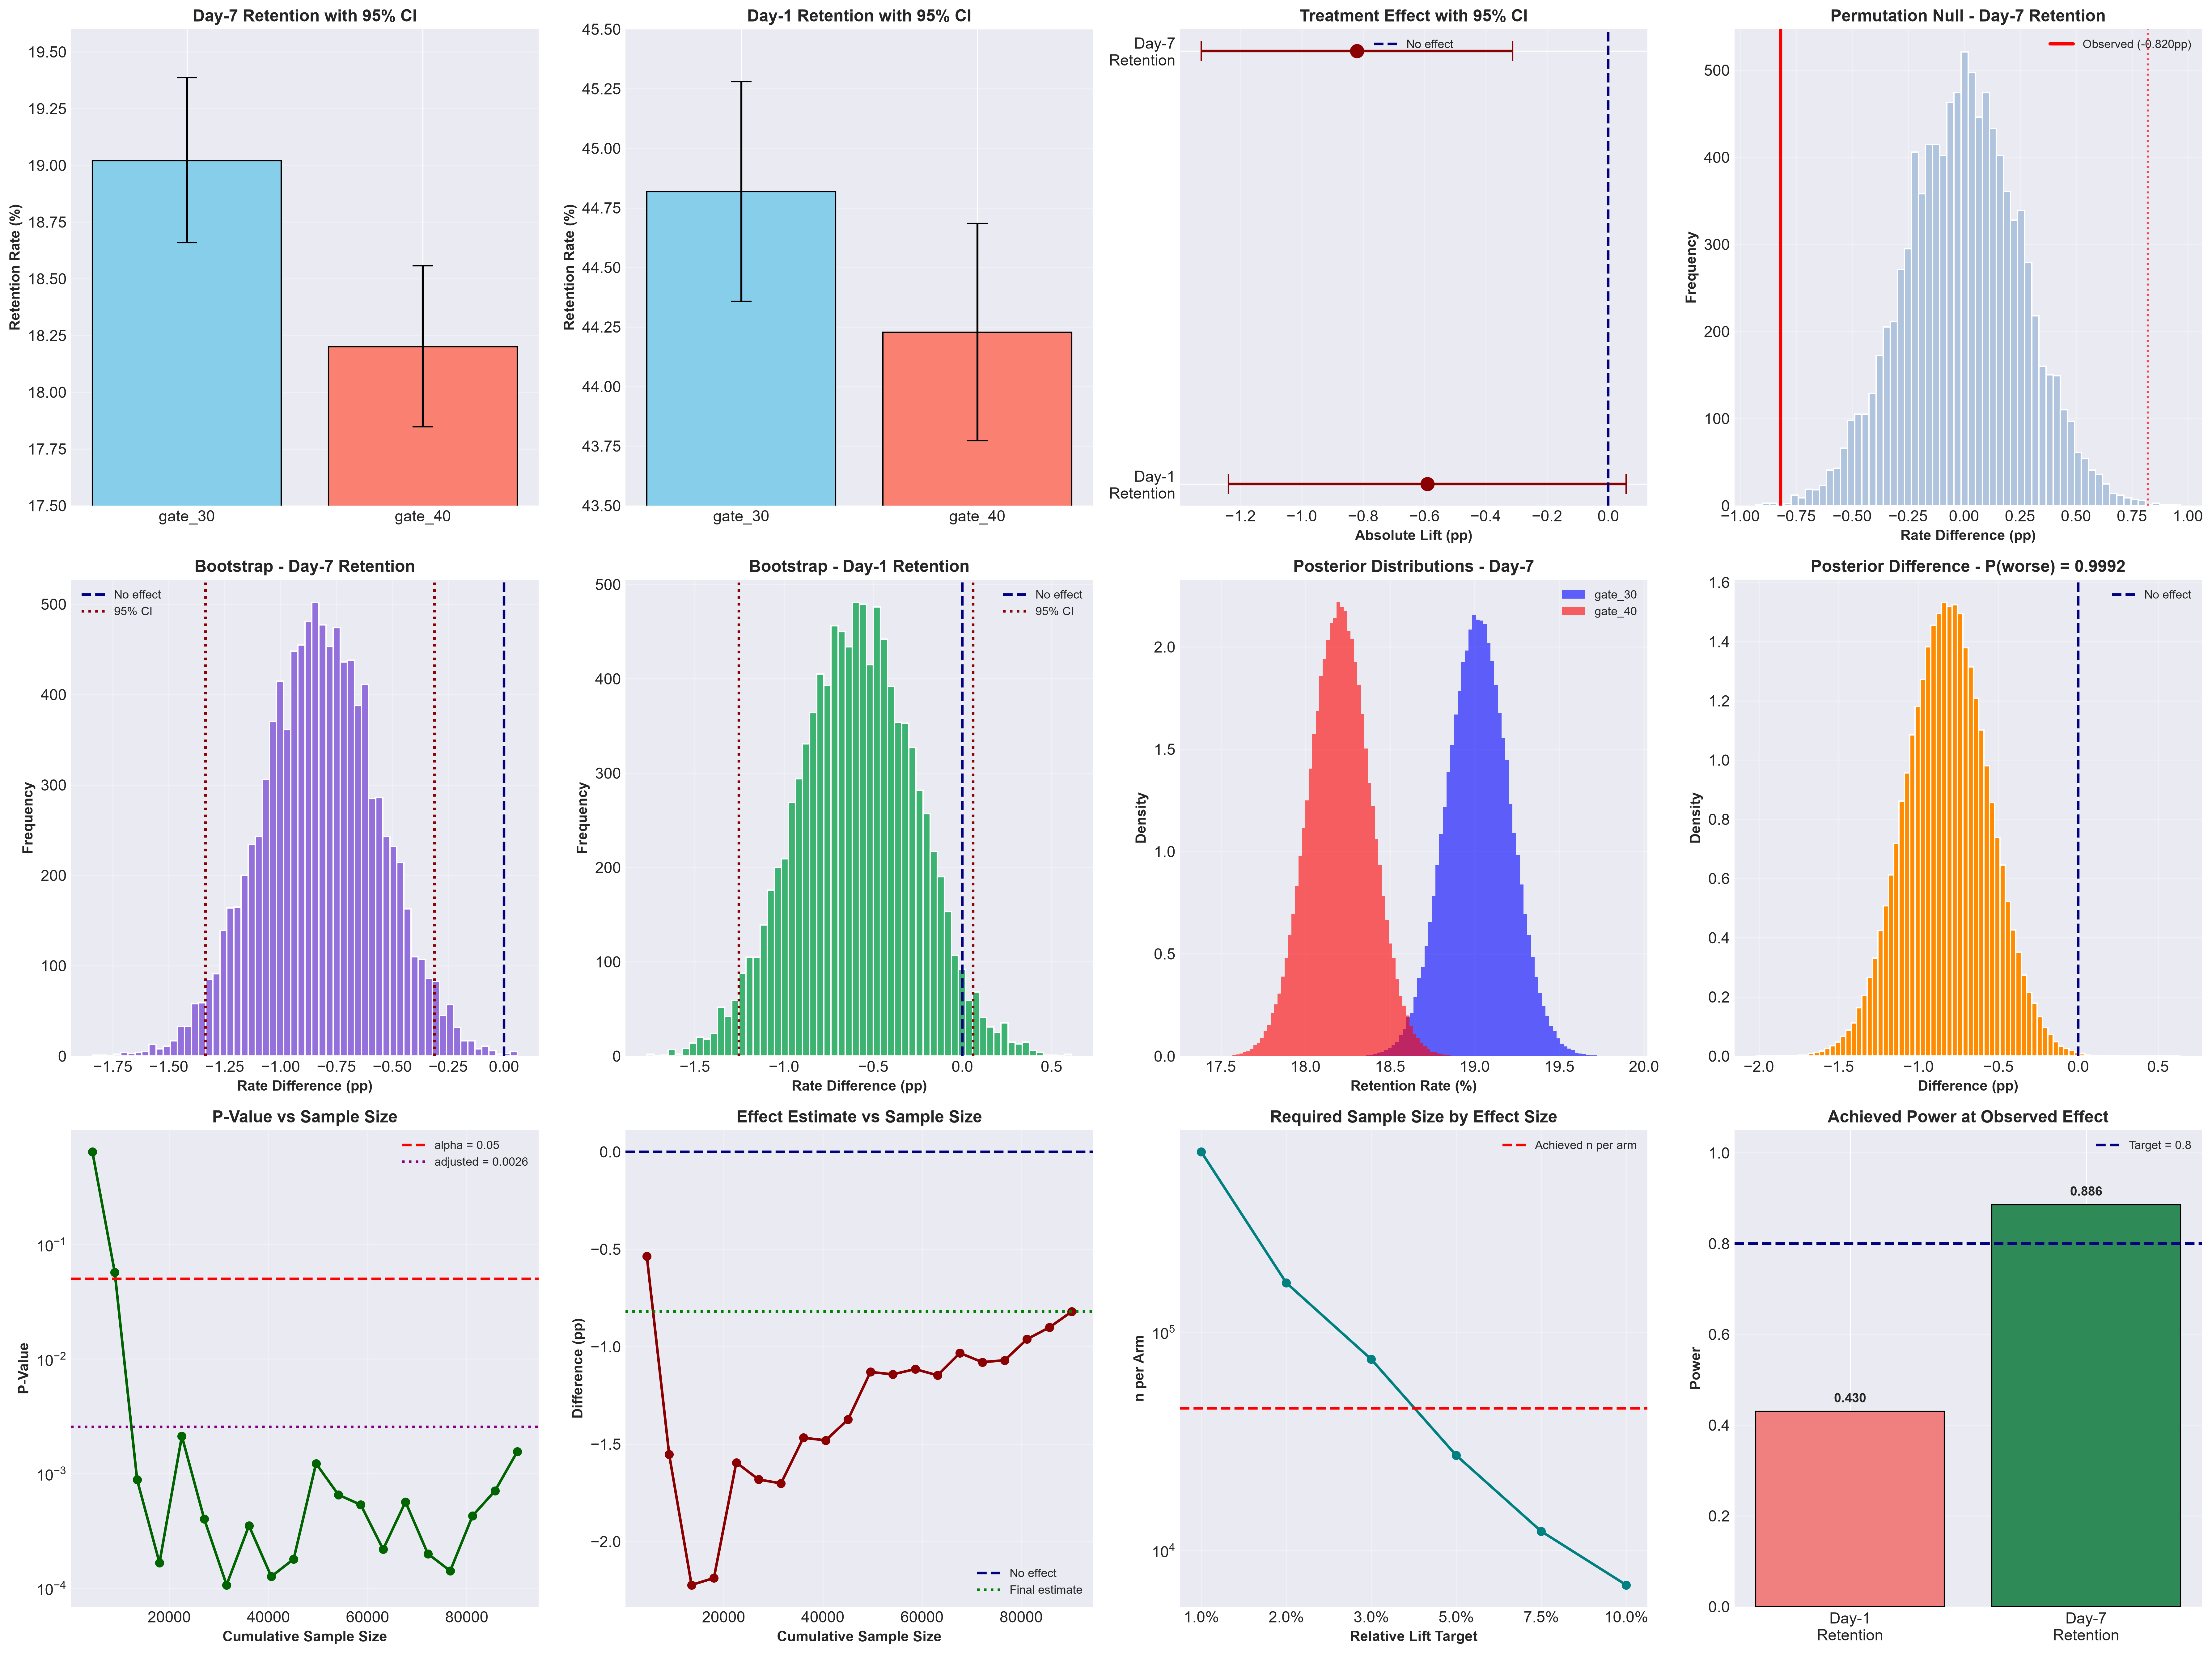

In [98]:
# Power Comparison Across Metrics
ax12 = plt.subplot(3, 4, 12)
power_labels = ['Day-1\nRetention', 'Day-7\nRetention']
power_values = [r1['achieved_power'], r7['achieved_power']]
bars = ax12.bar(power_labels, power_values, color=['lightcoral', 'seagreen'], edgecolor='black')
ax12.axhline(POWER_TARGET, color='navy', lw=2, linestyle='--', label=f'Target = {POWER_TARGET}')
ax12.set_title('Achieved Power at Observed Effect', fontsize=13, fontweight='bold')
ax12.set_ylabel('Power', fontweight='bold', fontsize=11)
ax12.set_ylim(0, 1.05)
for i, v in enumerate(power_values):
    ax12.text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold', fontsize=10)
ax12.legend(fontsize=9)
ax12.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('outputs/experiment_results_comprehensive.png', dpi=300, bbox_inches='tight')
plt.close()
print("Results visualizations saved as 'outputs/experiment_results_comprehensive.png'")
display(Image(filename='outputs/experiment_results_comprehensive.png', width=1100))

## ***Decision Summary***

In [99]:
# Assemble the metric result table
summary_rows = []
for key, res in metric_results.items():
    summary_rows.append({
        'metric': key,
        'control_rate': round(res['rate_control'], 6),
        'treatment_rate': round(res['rate_treatment'], 6),
        'absolute_lift_pp': round(res['absolute_lift']*100, 4),
        'relative_lift_pct': round(res['relative_lift']*100, 4),
        'ci_low_pp': round(res['ci_low']*100, 4),
        'ci_high_pp': round(res['ci_high']*100, 4),
        'pvalue': round(res['z_pvalue'], 6),
        'achieved_power': round(res['achieved_power'], 4),
        'significant': res['z_pvalue'] < ALPHA,
    })

results_df = pd.DataFrame(summary_rows).set_index('metric')
results_df = results_df.loc[[PRIMARY_METRIC, SECONDARY_METRIC]]
print(results_df.to_string())

             control_rate  treatment_rate  absolute_lift_pp  relative_lift_pct  ci_low_pp  ci_high_pp    pvalue  achieved_power  significant
metric                                                                                                                                      
retention_7      0.190201        0.182000           -0.8201            -4.3119    -1.3282     -0.3121  0.001554          0.8858         True
retention_1      0.448188        0.442283           -0.5905            -1.3176    -1.2392      0.0582  0.074410          0.4303        False


In [100]:
# Final decision on the primary metric
print(f"EXPERIMENT DECISION".center(100))
print(f"Primary metric: {PRIMARY_METRIC}")
print(f"Observed effect: {r7['absolute_lift']*100:+.4f}pp ({r7['relative_lift']*100:+.4f}% relative)")
print(f"95% confidence interval: [{r7['ci_low']*100:+.4f}pp, {r7['ci_high']*100:+.4f}pp]")
print(f"P-value: {r7['z_pvalue']:.6f}")
print(f"Bayesian P({TREATMENT} better): {bayes_r7['prob_treatment_better']:.5f}")
print(f"Achieved power: {r7['achieved_power']:.4f}")
print(f"Decision: DO NOT SHIP {TREATMENT}")

                                        EXPERIMENT DECISION                                         
Primary metric: retention_7
Observed effect: -0.8201pp (-4.3119% relative)
95% confidence interval: [-1.3282pp, -0.3121pp]
P-value: 0.001554
Bayesian P(gate_40 better): 0.00076
Achieved power: 0.8858
Decision: DO NOT SHIP gate_40


In [101]:
# Projected impact of shipping the treatment at scale
COHORT_SIZE = 100000
projected_loss = abs(r7['absolute_lift']) * COHORT_SIZE
projected_loss_low = abs(r7['ci_high']) * COHORT_SIZE
projected_loss_high = abs(r7['ci_low']) * COHORT_SIZE

print(f"Projected Impact per {COHORT_SIZE:,} New Installs")
print(f"Day-7 retained players lost: {projected_loss:.0f}")
print(f"95% interval: {projected_loss_low:.0f} to {projected_loss_high:.0f} players")

Projected Impact per 100,000 New Installs
Day-7 retained players lost: 820
95% interval: 312 to 1328 players


In [102]:
# Secondary metric conclusion
print(f"Secondary Metric Status")
print(f"Metric: {SECONDARY_METRIC}")
print(f"Observed effect: {r1['absolute_lift']*100:+.4f}pp")
print(f"P-value: {r1['z_pvalue']:.6f} (threshold {ALPHA})")
print(f"Achieved power at observed effect: {r1['achieved_power']:.4f}")
print(f"Sample size per arm required for {POWER_TARGET:.0%} power: {int(np.ceil(n_needed_r1))}")
print(f"Status: INCONCLUSIVE - underpowered at this sample size")

Secondary Metric Status
Metric: retention_1
Observed effect: -0.5905pp
P-value: 0.074410 (threshold 0.05)
Achieved power at observed effect: 0.4303
Sample size per arm required for 80% power: 111190
Status: INCONCLUSIVE - underpowered at this sample size


In [103]:
# Guardrail metric conclusion
print(f"Guardrail Metric Status")
print(f"Metric: {GUARDRAIL_METRIC}")
print(f"Mean difference (outlier excluded): {rounds_treatment_clean.mean() - rounds_control_clean.mean():+.4f} rounds")
print(f"P-value: {welch_p_clean:.6f} (threshold {ALPHA})")
print(f"Status: NO DEGRADATION DETECTED")

Guardrail Metric Status
Metric: sum_gamerounds
Mean difference (outlier excluded): -0.0433 rounds
P-value: 0.949469 (threshold 0.05)
Status: NO DEGRADATION DETECTED


## ***Saving Results***

In [104]:
# Save metric comparison results
results_df.to_csv('outputs/experiment_results.csv')
print("Metric results saved as 'outputs/experiment_results.csv'")

Metric results saved as 'outputs/experiment_results.csv'


In [105]:
# Save the sequential analysis path
sequential_df.to_csv('outputs/sequential_analysis.csv', index=False)
print("Sequential analysis saved as 'outputs/sequential_analysis.csv'")

Sequential analysis saved as 'outputs/sequential_analysis.csv'


In [106]:
# Save the sample size planning table
sample_size_df.to_csv('outputs/sample_size_requirements.csv', index=False)
print("Sample size table saved as 'outputs/sample_size_requirements.csv'")

Sample size table saved as 'outputs/sample_size_requirements.csv'


In [107]:
# Save detailed results summary
with open('outputs/experiment_summary.txt', 'w') as f:
    f.write("MOBILE GAME A/B TEST - EXPERIMENT SUMMARY\n\n")

    f.write("EXPERIMENT INFORMATION\n")
    f.write(f"Control group: {CONTROL}\n")
    f.write(f"Treatment group: {TREATMENT}\n")
    f.write(f"Total players: {len(df)}\n")
    f.write(f"Control players: {n_control}\n")
    f.write(f"Treatment players: {n_treatment}\n")
    f.write(f"Primary metric: {PRIMARY_METRIC}\n")
    f.write(f"Significance level: {ALPHA}\n\n")

    f.write("VALIDITY CHECKS\n")
    f.write(f"Sample ratio mismatch p-value: {srm_p:.6f}\n")
    f.write(f"SRM verdict at 0.0005 threshold: {'ALERT' if srm_p < 0.0005 else 'PASS'}\n")
    f.write(f"Records above {OUTLIER_THRESHOLD} game rounds: {len(outliers)}\n\n")

    f.write("METRIC RESULTS\n")
    f.write(results_df.to_string())
    f.write("\n\n")

    f.write("PRIMARY METRIC DETAIL\n")
    f.write(f"Absolute lift: {r7['absolute_lift']*100:+.4f}pp\n")
    f.write(f"Relative lift: {r7['relative_lift']*100:+.4f}%\n")
    f.write(f"95% CI: [{r7['ci_low']*100:+.4f}pp, {r7['ci_high']*100:+.4f}pp]\n")
    f.write(f"z-test p-value: {r7['z_pvalue']:.6f}\n")
    f.write(f"Chi-square p-value: {r7['chi2_pvalue']:.6f}\n")
    f.write(f"Fisher exact p-value: {r7['fisher_pvalue']:.6f}\n")
    f.write(f"Permutation p-value: {perm_p_r7:.6f}\n")
    f.write(f"Bayesian P(treatment better): {bayes_r7['prob_treatment_better']:.5f}\n")
    f.write(f"Achieved power: {r7['achieved_power']:.4f}\n\n")

    f.write("MULTIPLE TESTING CORRECTION\n")
    f.write(pvalue_table.round(6).to_string(index=False))
    f.write("\n\n")

    f.write("PEEKING SIMULATION\n")
    f.write(f"False positive rate at final look only: {fixed_error:.4f}\n")
    f.write(f"False positive rate across 20 looks: {peek_error:.4f}\n")
    f.write(f"Inflation factor: {peek_error/fixed_error:.2f}x\n\n")

    f.write("DECISION\n")
    f.write(f"Do not ship {TREATMENT}\n")
    f.write(f"Projected day-7 retained players lost per {COHORT_SIZE:,} installs: {projected_loss:.0f}\n")

print("Experiment summary saved as 'outputs/experiment_summary.txt'")

Experiment summary saved as 'outputs/experiment_summary.txt'


## ***Streamlit***

In [108]:
# Save experiment results for the Streamlit application
app_payload = {
    'control': CONTROL,
    'treatment': TREATMENT,
    'alpha': ALPHA,
    'power_target': POWER_TARGET,
    'n_control': int(n_control),
    'n_treatment': int(n_treatment),
    'srm_pvalue': float(srm_p),
    'metrics': {},
}

for key, res in metric_results.items():
    app_payload['metrics'][key] = {
        'x_control': int(res['x_control']), 'n_control': int(res['n_control']),
        'x_treatment': int(res['x_treatment']), 'n_treatment': int(res['n_treatment']),
        'rate_control': float(res['rate_control']), 'rate_treatment': float(res['rate_treatment']),
        'absolute_lift': float(res['absolute_lift']), 'relative_lift': float(res['relative_lift']),
        'ci_low': float(res['ci_low']), 'ci_high': float(res['ci_high']),
        'pvalue': float(res['z_pvalue']), 'achieved_power': float(res['achieved_power']),
    }

try:
    with open('outputs/experiment_payload.json', 'w') as f:
        json.dump(app_payload, f, indent=2)
    print("Experiment payload saved as 'outputs/experiment_payload.json'")
except Exception as e:
    print(f"Error saving experiment payload: {e}")

Experiment payload saved as 'outputs/experiment_payload.json'


In [109]:
# Confirm the saved artifacts
for artifact in ['outputs/experiment_results.csv', 'outputs/sequential_analysis.csv',
                 'outputs/sample_size_requirements.csv', 'outputs/experiment_summary.txt',
                 'outputs/experiment_payload.json', 'outputs/eda_comprehensive_analysis.png',
                 'outputs/experiment_results_comprehensive.png']:
    print(f"{artifact}: {'saved' if os.path.exists(artifact) else 'MISSING'}")

outputs/experiment_results.csv: saved
outputs/sequential_analysis.csv: saved
outputs/sample_size_requirements.csv: saved
outputs/experiment_summary.txt: saved
outputs/experiment_payload.json: saved
outputs/eda_comprehensive_analysis.png: saved
outputs/experiment_results_comprehensive.png: saved
